# MODULE 3: SHAP tutorials
# CLASSIFIER: Logistic regression



*   Task: classification
*   Model: logistic regression
*   Dataset: adult (from Shap repository)



## DATASET

* Dataset: adult
* Originally from UCI repository
* shap library own copy of dataset

Categorical features: 'Workclass', 'Marital Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Country'

Numerical features: 'Age', 'Education-Num', 'Capital Gain', 'Capital Loss', 'Hours per week'


In [3]:
import shap
from sklearn.model_selection import train_test_split
X, y = shap.datasets.adult()
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=1
)



## BUILDING THE MODEL: LOGISTIC REGRESSION


Pipeline:
* All numerical features are **standardized**.
* All categorical features are **one-hot encoded**.
* Logistic regression


Logistic Regression outuputs:

* The **probability of earning less** than $50k.

* The **probability of earning more** than $50k.




In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

import numpy as np


# Define the categorical and numerical features
cats = ['Workclass', 'Marital Status', 'Occupation',
        'Relationship', 'Race', 'Sex', 'Country']
nums = ['Age', 'Education-Num', 'Capital Gain',
        'Capital Loss', 'Hours per week']

# Define the column transformer (how to transform data)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), cats),
        ('num', StandardScaler(), nums)
    ])

# Define the pipeline: preprocesing 2 columns and LogRegression
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=10000))
])

# Fit the pipeline to the training data
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['Workclass',
                                                   'Marital Status',
                                                   'Occupation', 'Relationship',
                                                   'Race', 'Sex', 'Country']),
                                                 ('num', StandardScaler(),
                                                  ['Age', 'Education-Num',
                                                   'Capital Gain',
                                                   'Capital Loss',
                                                   'Hours per week'])])),
                ('classifier', LogisticRegression(max_iter=10000))])

# Creating SHAP explainer

* X_sub: subset of training set to be explained.
*  **Applying SHAP**  to the **entire pipeline**


💡 SHAP applied not just to the model. Aplying to the whole pipeline  allows us to compute SHAP values for the **original features** instead of their processed versions.

In [5]:
X_sub = shap.sample(X_train, 100)
ex = shap.Explainer(model.predict_proba, X_sub)
shap_values = ex(X_test.iloc[0:100])

PermutationExplainer explainer: 101it [01:08,  1.46it/s]                         


### WATERFALL plot
### Explanation for instance 1 when predicting more $50k

Prediction of earning more than $50k was 0.01% likelyhood.

The general expected prediction is 22%



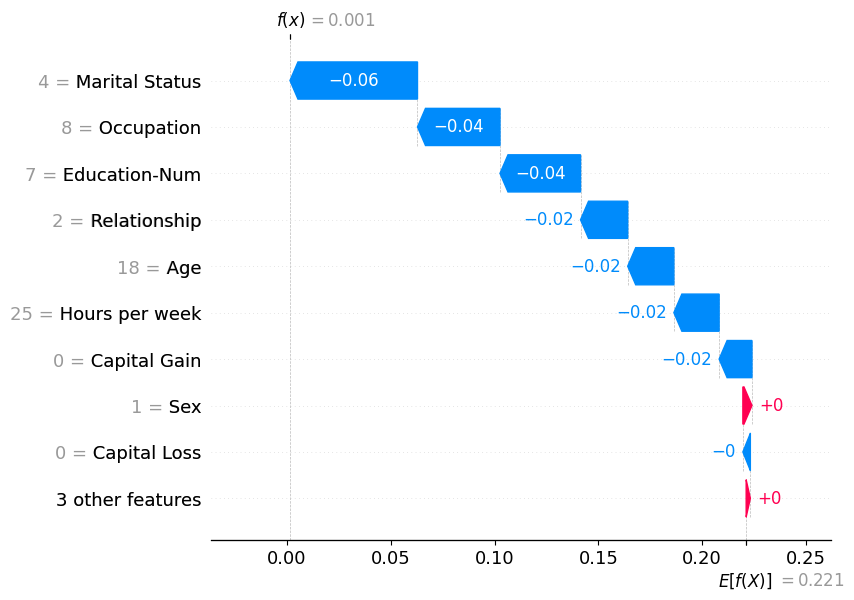

In [14]:
data_index = 1
class_index = 1

shap.plots.waterfall(shap_values[data_index,:,class_index])

### WATERFALL plot 2
### Explanation for instance 1 when predicting less $50k

Prediction of earning more than $50k was 0.99% likelyhood.

The general expected prediction is 77.9%

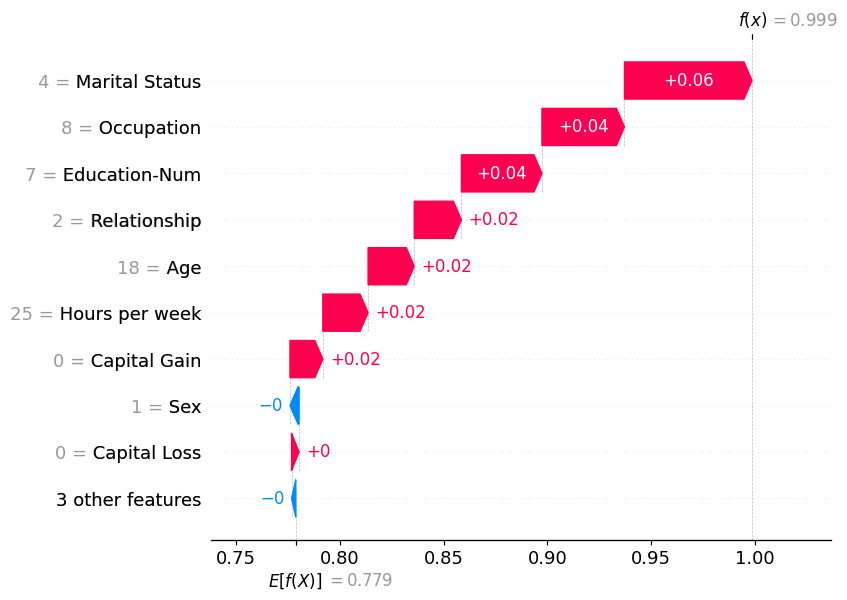

In [15]:
data_index = 1
class_index = 0
shap.plots.waterfall(shap_values[data_index,:,class_index])

### FORCE PLOT


In [8]:
data_index = 1
class_index = 0

# need to initialise JavaScript for notebooks
shap.initjs()

#plotting Force plot
shap.plots.force(shap_values[data_index,:,class_index])


In [9]:
data_index = 1
class_index = 1

shap.initjs()
shap.plots.force(shap_values[data_index,:,class_index])